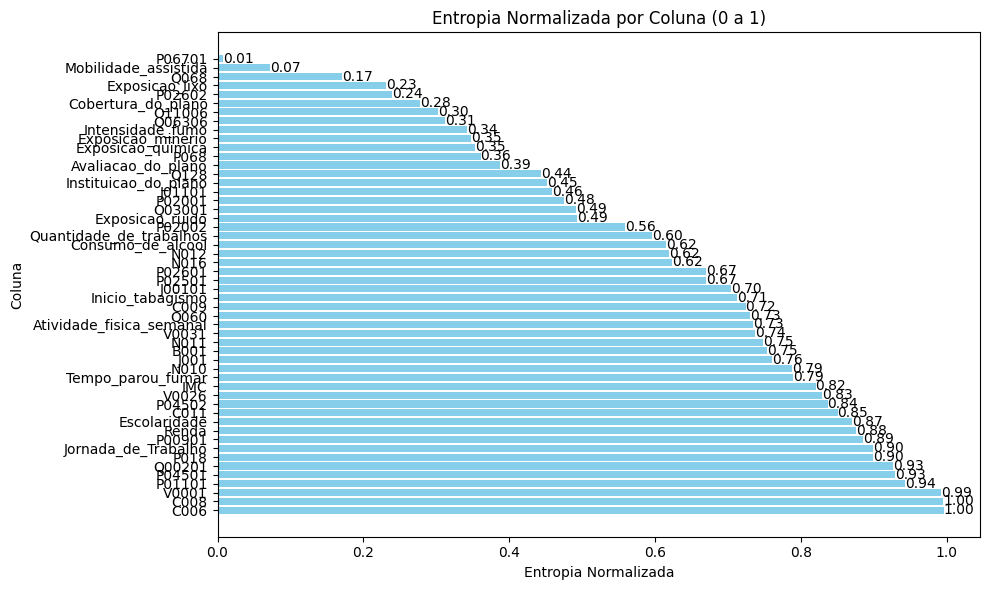


Resultados da Análise de Entropia Normalizada:
                  Coluna  Entropia Normalizada (0-1)  Entropia Bruta (bits)  Valores Únicos Tipo de Dado
                    C006                    0.995639               0.995639               2      float64
                    C008                    0.995258               4.930704              31      float64
                   V0001                    0.992063               3.671069              13        int64
                  P01101                    0.943057               2.829170               8      float64
                  P04501                    0.929349               2.402332               6      float64
                  Q00201                    0.925811               0.925811               2      float64
                    P018                    0.898589               2.695766               8      float64
     Jornada_de_Trabalho                    0.898561               1.424186               3        int64
       

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def calcular_entropia_normalizada(coluna, base=2):
    """
    Calcula a entropia de Shannon normalizada (0 a 1) de uma coluna do DataFrame.
    
    Parâmetros:
    coluna (pd.Series): Coluna do DataFrame a ser analisada
    base (int): Base do logaritmo (2 para bits)
    
    Retorna:
    float: Valor da entropia normalizada entre 0 e 1
    """
    # Conta a frequência de cada valor único
    contador = Counter(coluna.dropna())  # Remove valores nulos
    total = len(coluna.dropna())
    
    if total == 0:
        return 0.0
    
    # Calcula as probabilidades
    probabilidades = np.array([contador[x]/total for x in contador])
    
    # Remove probabilidades zero para evitar problemas com log
    probabilidades = probabilidades[probabilidades > 0]
    
    # Calcula a entropia
    entropia = -np.sum(probabilidades * np.log(probabilidades)) / np.log(base)
    
    # Calcula a entropia máxima possível (log(N) na base 2)
    N = len(contador)
    if N <= 1:
        return 0.0  # Evita divisão por zero para coluna constante
    
    entropia_maxima = np.log(N) / np.log(base)
    
    # Normaliza a entropia entre 0 e 1
    entropia_normalizada = entropia / entropia_maxima
    
    return entropia_normalizada

def analisar_entropia_dataframe(df):
    """
    Analisa a entropia normalizada de todas as colunas de um DataFrame.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame a ser analisado
    
    Retorna:
    pd.DataFrame: DataFrame com os resultados de entropia normalizada
    """
    resultados = []
    
    for coluna in df.columns:
        # Calcula entropia normalizada para cada coluna
        entropia_norm = calcular_entropia_normalizada(df[coluna])
        
        # Calcula também a entropia bruta para referência
        entropia_bruta = calcular_entropia_normalizada(df[coluna]) * (np.log(df[coluna].nunique()) / np.log(2)) if df[coluna].nunique() > 1 else 0
        
        # Conta valores únicos
        valores_unicos = df[coluna].nunique()
        
        # Adiciona aos resultados
        resultados.append({
            'Coluna': coluna,
            'Entropia Normalizada (0-1)': entropia_norm,
            'Entropia Bruta (bits)': entropia_bruta,
            'Valores Únicos': valores_unicos,
            'Tipo de Dado': df[coluna].dtype
        })
    
    # Cria DataFrame de resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Ordena por entropia decrescente
    df_resultados = df_resultados.sort_values('Entropia Normalizada (0-1)', ascending=False)
    
    # Plota gráfico de entropia
    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_resultados['Coluna'], df_resultados['Entropia Normalizada (0-1)'], color='skyblue')
    plt.title('Entropia Normalizada por Coluna (0 a 1)')
    plt.xlabel('Entropia Normalizada')
    plt.ylabel('Coluna')
    
    # Adiciona valores nas barras
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return df_resultados

# Carrega seus dados
df = pd.read_csv("../Bases/Criados/5_base_codificada.csv")

# Analisa a entropia normalizada
resultados_entropia = analisar_entropia_dataframe(df)

# Mostra os resultados
print("\nResultados da Análise de Entropia Normalizada:")
print(resultados_entropia.to_string(index=False))

# Salva os resultados em CSV se desejar
# resultados_entropia.to_csv("resultados_entropia_normalizada.csv", index=False)